Lendo o DataSet

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.core.display_functions import display
import seaborn as sns
from src.util.graifcos import graf_evolu_pais, Coluna, gerar_barh_grafico, Posicao


In [2]:
DATA_SET_PATH = '../datasets'

In [3]:
df = pd.read_csv(os.path.join(DATA_SET_PATH, 'gapminder_full.csv'))

In [4]:
df.head(10)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
5,Afghanistan,1977,14880372.0,Asia,38.438,786.113360
6,Afghanistan,1982,12881816.0,Asia,39.854,978.011439
7,Afghanistan,1987,13867957.0,Asia,40.822,852.395945
8,Afghanistan,1992,16317921.0,Asia,41.674,649.341395
9,Afghanistan,1997,22227415.0,Asia,41.763,635.341351


In [5]:
df.head(5)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Verificando Schema

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1736 non-null   str    
 1   year       1736 non-null   int64  
 2   pop        1736 non-null   float64
 3   continent  1736 non-null   str    
 4   lifeExp    1736 non-null   float64
 5   gdpPercap  1736 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 81.5 KB


## Limpeza

### Verificando duplicações

In [7]:
df.shape

(1736, 6)

In [8]:
df.duplicated().sum()

np.int64(32)

In [9]:
df.duplicated().mean() * 100

np.float64(1.8433179723502304)

In [10]:
df.duplicated(subset=['country', 'year']).sum()


np.int64(32)

In [11]:
df.duplicated().mean() * 100

np.float64(1.8433179723502304)

#### A chave lógica é country e year?  Realmente existe duplicados?

In [12]:
valida_chave = (
    df.groupby(['country', 'year'])
    .agg(
        qtd_linhas = ('country', 'size'),
        qtd_populacao = ('pop', 'nunique'),
        qtd_continent = ('continent', 'nunique'),
        qtd_lifexp = ('lifeExp', 'nunique'),
        qtd_gpdPercap = ('gdpPercap', 'nunique')
    )
    .reset_index()
)
valida_chave.sort_values("qtd_linhas", ascending = False).head(5)

,country,year,qtd_linhas,qtd_populacao,qtd_continent,qtd_lifexp,qtd_gpdPercap
199,Burkina Faso,1987,2,1,1,1,1
534,France,1982,2,1,1,1,1
533,France,1977,2,1,1,1,1
9,Afghanistan,1997,2,1,1,1,1
532,France,1972,2,1,1,1,1


In [13]:
problemas_chave = valida_chave[
    ( valida_chave['qtd_linhas'] > 1 ) &
    (
        ( valida_chave['qtd_populacao'] > 1 ) |
        (valida_chave['qtd_continent'] > 1 ) |
        (valida_chave['qtd_lifexp'] > 1 ) |
        (valida_chave['qtd_gpdPercap'] > 1 )
    )
]

In [14]:
dups_chave = df[df.duplicated(subset=['country', 'year'], keep=False)].sort_values(by=['country', 'year'])

##### Duplicaçcoes é de um lote especifico ou mais concentrado em algum país?

###### Concentração de duplicados por pais

In [15]:
filter_dups_first = df.duplicated(subset=["country", 'year'], keep='first')

In [16]:

dups_por_pais = (
    df[filter_dups_first].groupby(['country'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='qtd_linhas_duplicadas')
)
dups_por_pais

,country,qtd_linhas_duplicadas
0,France,7
1,Guinea,5
2,Bolivia,5
3,Ecuador,3
4,Equatorial Guinea,3
5,China,3
6,Czech Republic,2
7,Belgium,1
8,Afghanistan,1
9,Burkina Faso,1


###### Concentração de duplicados por ano

In [17]:
dups_ano = (
    df[filter_dups_first].groupby('year')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='qtd_linhas_duplicadas')
)
dups_ano

,year,qtd_linhas_duplicadas
0,2007,6
1,1997,5
2,2002,5
3,1987,4
4,1972,2
5,1992,2
6,1962,2
7,1967,2
8,1952,1
9,1957,1


######  Visualizaçcoes Graficas de Duplicados

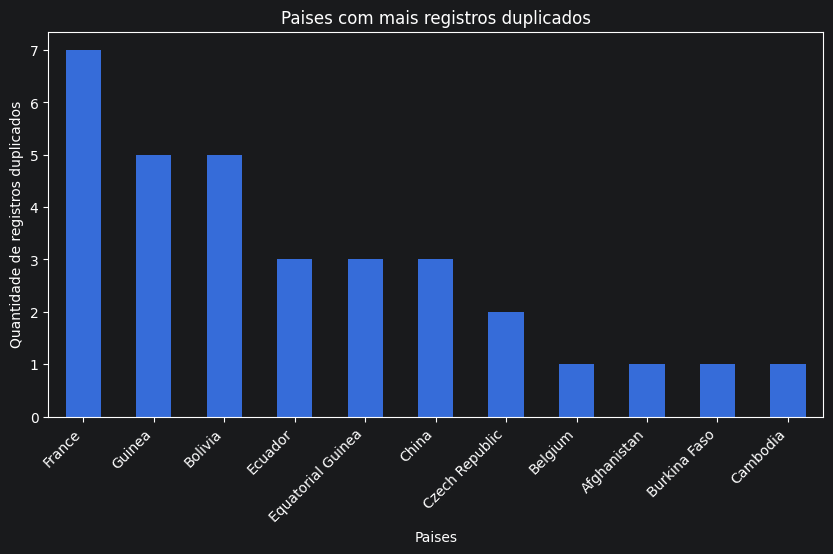

In [18]:
dups_por_pais.plot(kind='bar',x='country', y='qtd_linhas_duplicadas',legend=False,figsize=(10,5))
plt.title("Paises com mais registros duplicados")
plt.xlabel("Paises")
plt.ylabel("Quantidade de registros duplicados")
plt.xticks(rotation=45, ha='right')
plt.show()

In [19]:
matriz_dups = (
    dups_chave.groupby(['country', 'year'])
    .size()
    .unstack(fill_value=0)
)


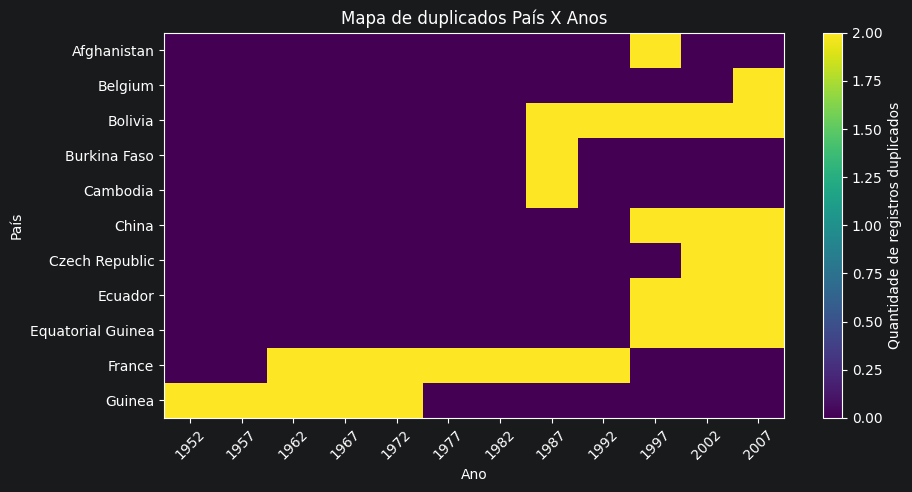

In [20]:
plt.figure(figsize=(10,5))
plt.imshow(matriz_dups, aspect='auto')
plt.title("Mapa de duplicados País X Anos")

plt.xlabel('Ano')
plt.ylabel('País')

plt.xticks(
    ticks=range(len(matriz_dups.columns)),
    labels=matriz_dups.columns,
    rotation=45,
)
plt.yticks(
    ticks=range(len(matriz_dups.index)),
    labels=matriz_dups.index,
)
plt.colorbar(label='Quantidade de registros duplicados')
plt.show()

####

##### Limpeza do Duplicadas

In [21]:
df = df.drop_duplicates()

Duplicados removidos?

In [22]:
df.groupby(['country', 'year']).nunique().max()

pop          1
continent    1
lifeExp      1
gdpPercap    1
dtype: int64

In [23]:
assert df.duplicated().sum() == 0

In [24]:
assert df.groupby(['country', 'year']).size().max() == 1

### Dados Ausentes?

In [25]:
df.isna().sum()

country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

### Ano esta no padrão de 4 digitos?

In [26]:
assert df['year'].astype('str').str.match(r'\d{4}').sum() == df.shape[0]

### Considerações Finais Limpeza e Tratamento

Após a análise dos registros duplicados, foi realizada a remoção dos duplicados exatos.
Em seguida, validou-se que não restaram linhas duplicadas, que a combinação `country-year`
permanece única e que não existem valores ausentes na base.
Com isso, o dataset foi considerado adequado para a etapa de Análise Exploratória de Dados.

Os tipos de dados estão apropriados para natureza de cada um. O float64 já é de alta precisa decimal e str é apropriado para as variaveis
categóricas

|           | Tipo    |
|:----------|:--------|
| country   | str     |
| year      | int64   |
| pop       | float64 |
| continent | str     |
| lifeExp   | float64 |
| gdpPercap | float64 |

O campo `year` temo o tipo apropriado e possui padrão bem definido e consistente

## Analises

### Entendendo o Dataset

O dataset apresenta informação agrupado por ano e pais

In [27]:
anos = df["year"].unique()
anos.shape

(12,)

In [28]:
anos

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [29]:
anos.shape

(12,)

In [30]:
df["country"].unique().shape

(142,)

In [31]:
countries_by_year = df.groupby('year')['country'].value_counts()
display(countries_by_year.shape)
countries_by_year.tail(10)


(1704,)

year  country           
2007  Angola                1
      Argentina             1
      Australia             1
      Nigeria               1
      West Bank and Gaza    1
      Zambia                1
      Austria               1
      Zimbabwe              1
      Bahrain               1
      Bangladesh            1
Name: count, dtype: int64

In [32]:
countries_by_year.max()

np.int64(1)

In [33]:
paises_por_ano = df.groupby('year')['country'].nunique().reset_index(name='qtd_paises')
display(paises_por_ano)


,year,qtd_paises
0,1952,142
1,1957,142
2,1962,142
3,1967,142
4,1972,142
5,1977,142
6,1982,142
7,1987,142
8,1992,142
9,1997,142


In [34]:
paises_por_ano.describe()

,year,qtd_paises
count,12.000000,12.0
mean,1979.500000,142.0
std,18.027756,0.0
min,1952.000000,142.0
25%,1965.750000,142.0
50%,1979.500000,142.0
75%,1993.250000,142.0
max,2007.000000,142.0


Para cada ano existe apenas um registro por pais, e para cada ano foram pesquisados 142 paises

Qual a periodicidade de pesquisa?

In [35]:
pd.Series(sorted(anos)).diff().dropna().value_counts()

5.0    11
Name: count, dtype: int64

In [36]:
anos_por_pais = df.groupby('country')['year']
qtde_anos = df['year'].nunique()
anos_por_pais.nunique().describe()

count    142.0
mean      12.0
std        0.0
min       12.0
25%       12.0
50%       12.0
75%       12.0
max       12.0
Name: year, dtype: float64

In [37]:
(
    anos_por_pais.nunique()
        .loc[lambda x : x < qtde_anos]
)


Series([], Name: year, dtype: int64)

In [38]:
matriz_temporal = df.assign(valor=1).pivot_table(index='country', columns='year', values='valor', fill_value=0)
matriz_temporal.head()

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
country,,,,,,,,,,,,
Afghanistan,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Albania,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Algeria,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Angola,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Argentina,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


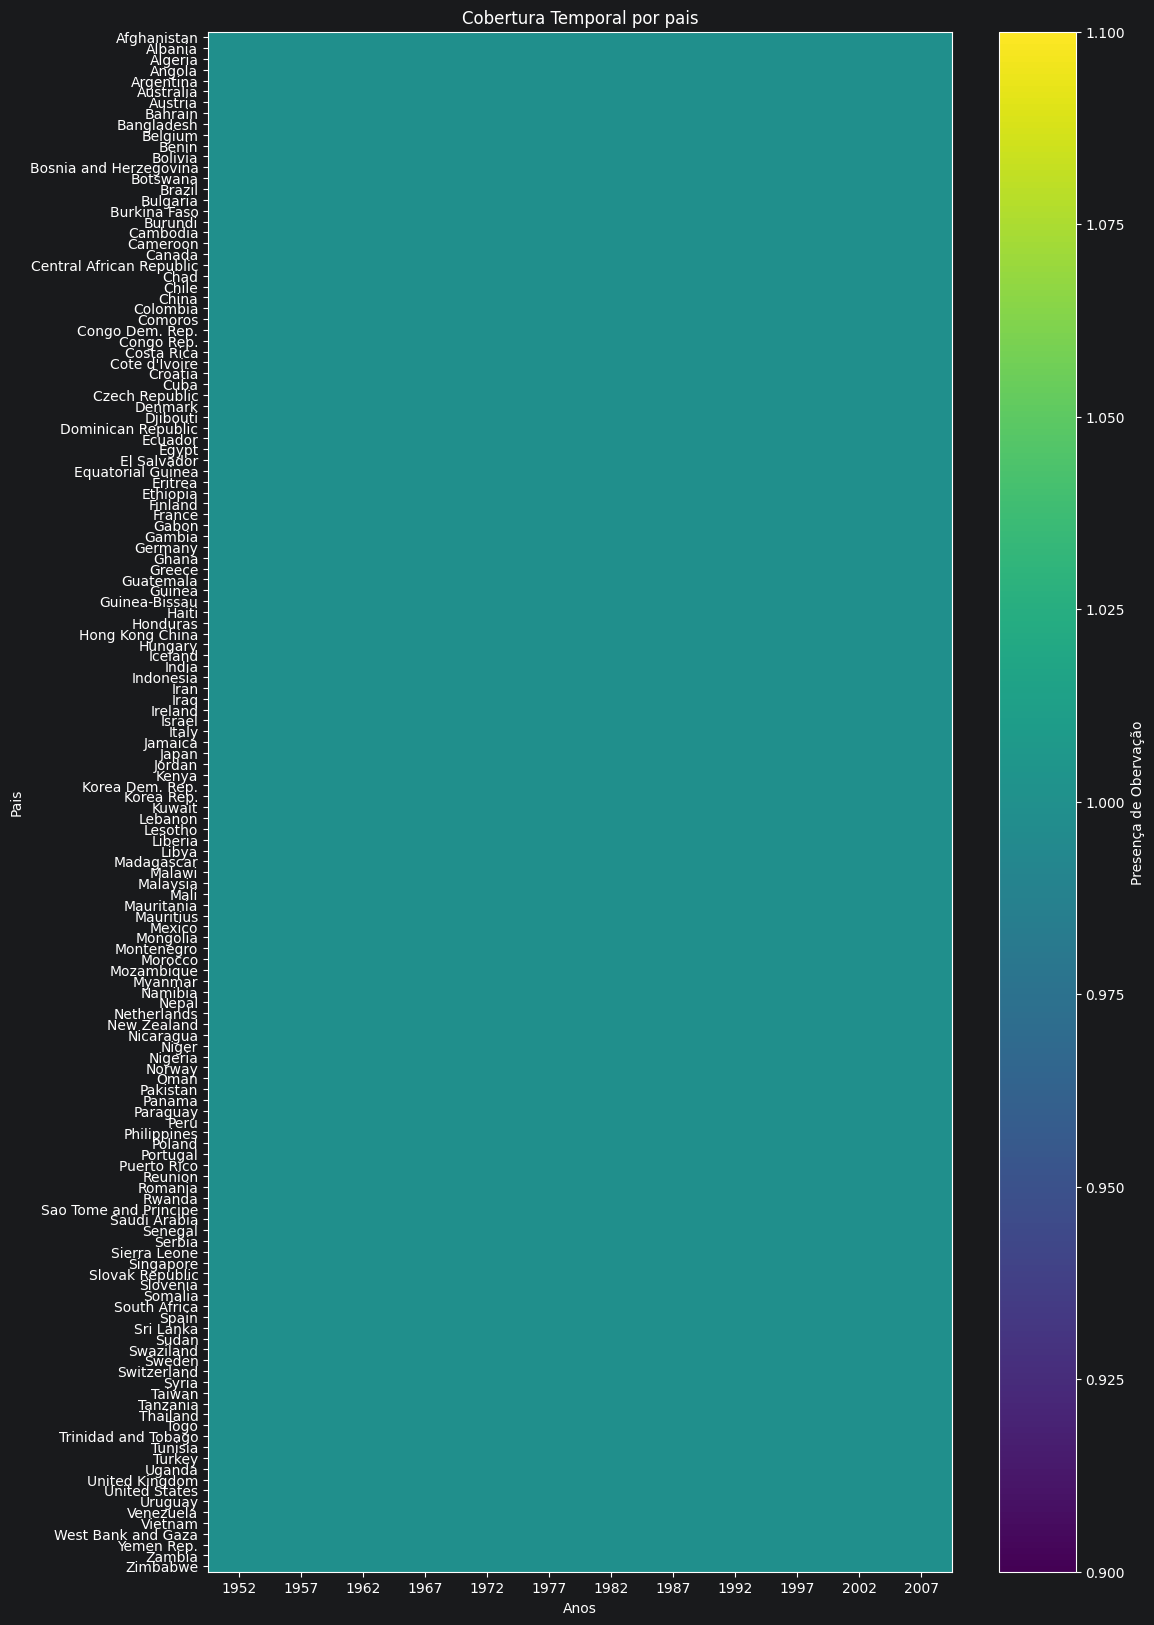

In [39]:
plt.figure(figsize=(12,20))
plt.imshow(matriz_temporal.values, aspect='auto')
plt.title("Cobertura Temporal por pais")
plt.xlabel('Anos')
plt.ylabel('Pais')
plt.xticks(ticks=range(len(matriz_temporal.columns)), labels=matriz_temporal.columns)
plt.yticks(ticks=range(len(matriz_temporal.index)), labels=matriz_temporal.index)
plt.colorbar(label='Presença de Obervação')
plt.show()

**_Estrutura Temporal do Dataset_**

Antes das análises exploratórias, foi realizada uma investigação da estrutura temporal do dataset para compreender a periodicidade das observações e verificar a consistência da cobertura entre os países.

A análise dos anos disponíveis mostrou que os dados são coletados em intervalos regulares de 5 anos, caracterizando uma periodicidade quinquenal.

Também foi avaliado se todos os países possuíam a mesma quantidade de observações ao longo do tempo. Essa verificação é importante para identificar possíveis séries temporais incompletas e garantir comparações consistentes entre países e continentes.

Os resultados indicam que o dataset possui estrutura temporal balanceada, com os países apresentando observações para os mesmos períodos históricos.

### Qual a expectativa de Vida Por Pais?



In [40]:
ano_mais_recente = df['year'].max()
ano_mais_antigo = df['year'].min()


In [41]:
colunas = (Coluna(nome_coluna="country", label="Pais", sortable=False),
           Coluna(nome_coluna="lifeExp", label="Pais", sortable=True))
[]


[]

#### Top 10 Pais Maior Expectativa

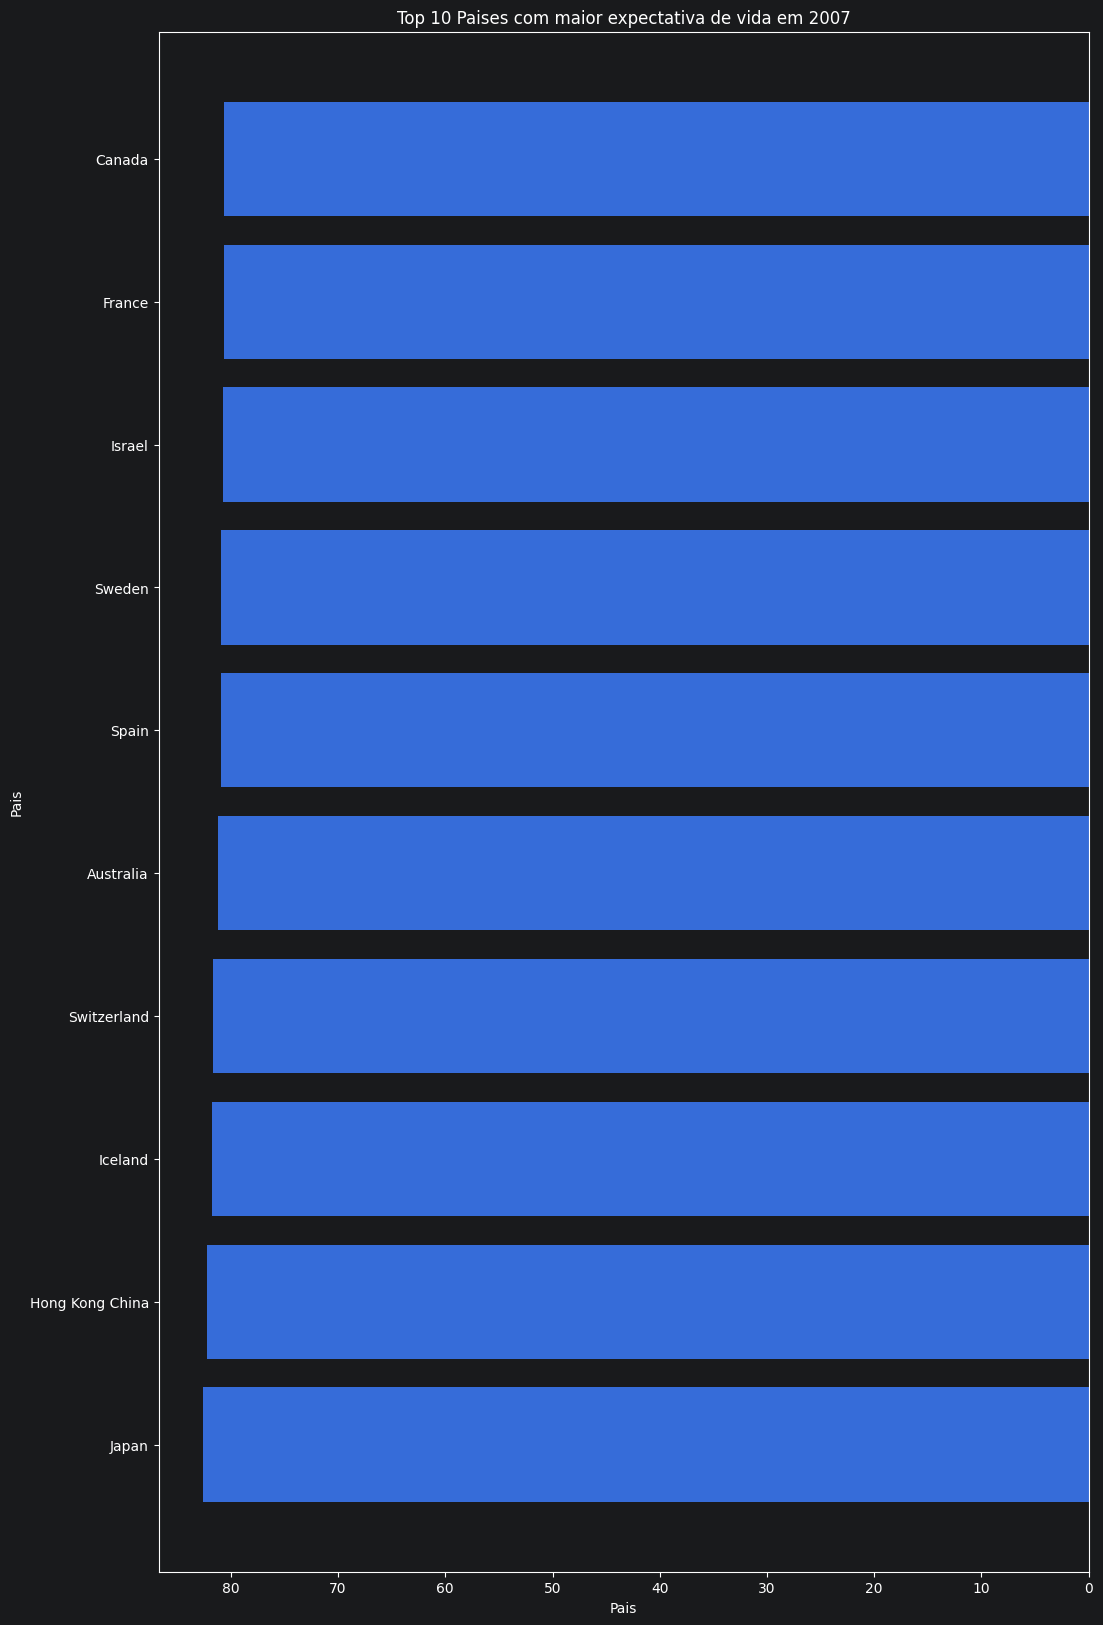

In [42]:

gerar_barh_grafico(
    ano=ano_mais_recente,
    data_frame=df,
    colunas=colunas,
    titulo=f"Top 10 Paises com maior expectativa de vida em {ano_mais_recente}",
    quantidade=10,
)

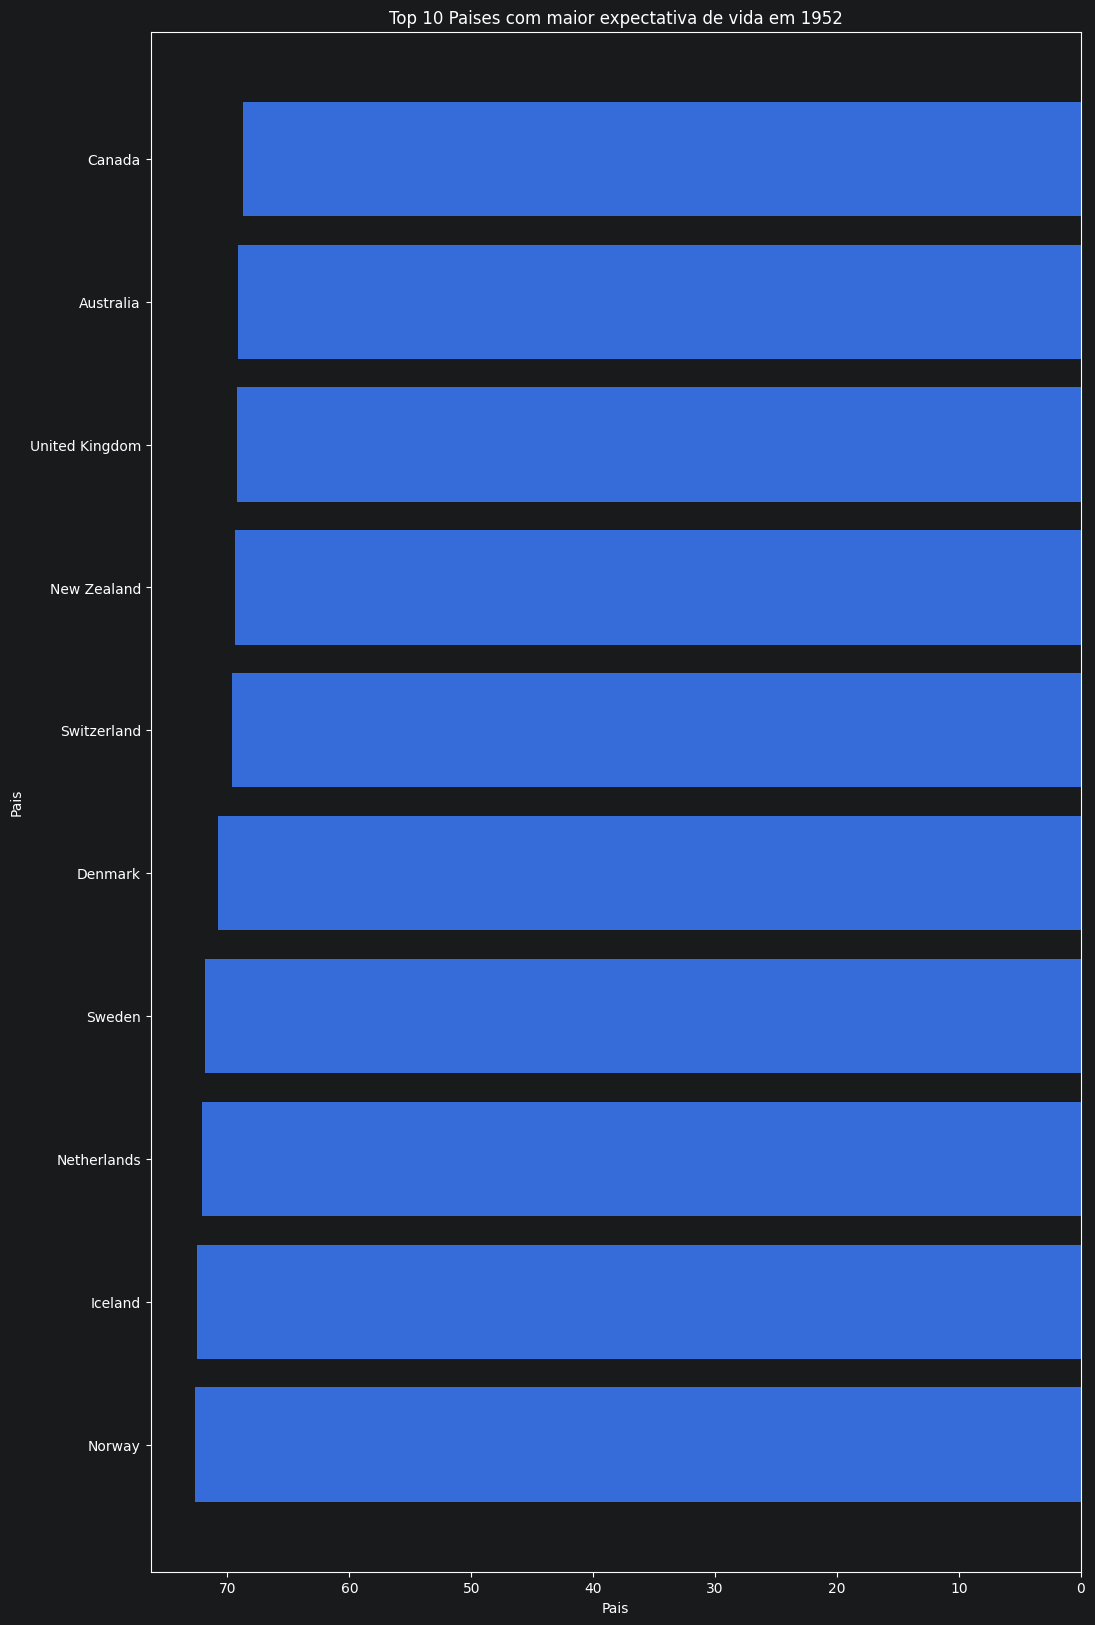

In [43]:
gerar_barh_grafico(
    ano=ano_mais_antigo,
    data_frame=df,
    colunas=colunas,
    titulo=f"Top 10 Paises com maior expectativa de vida em {ano_mais_antigo}",
    quantidade=10,
)

#### Top 10 Pais Menor Expectativa

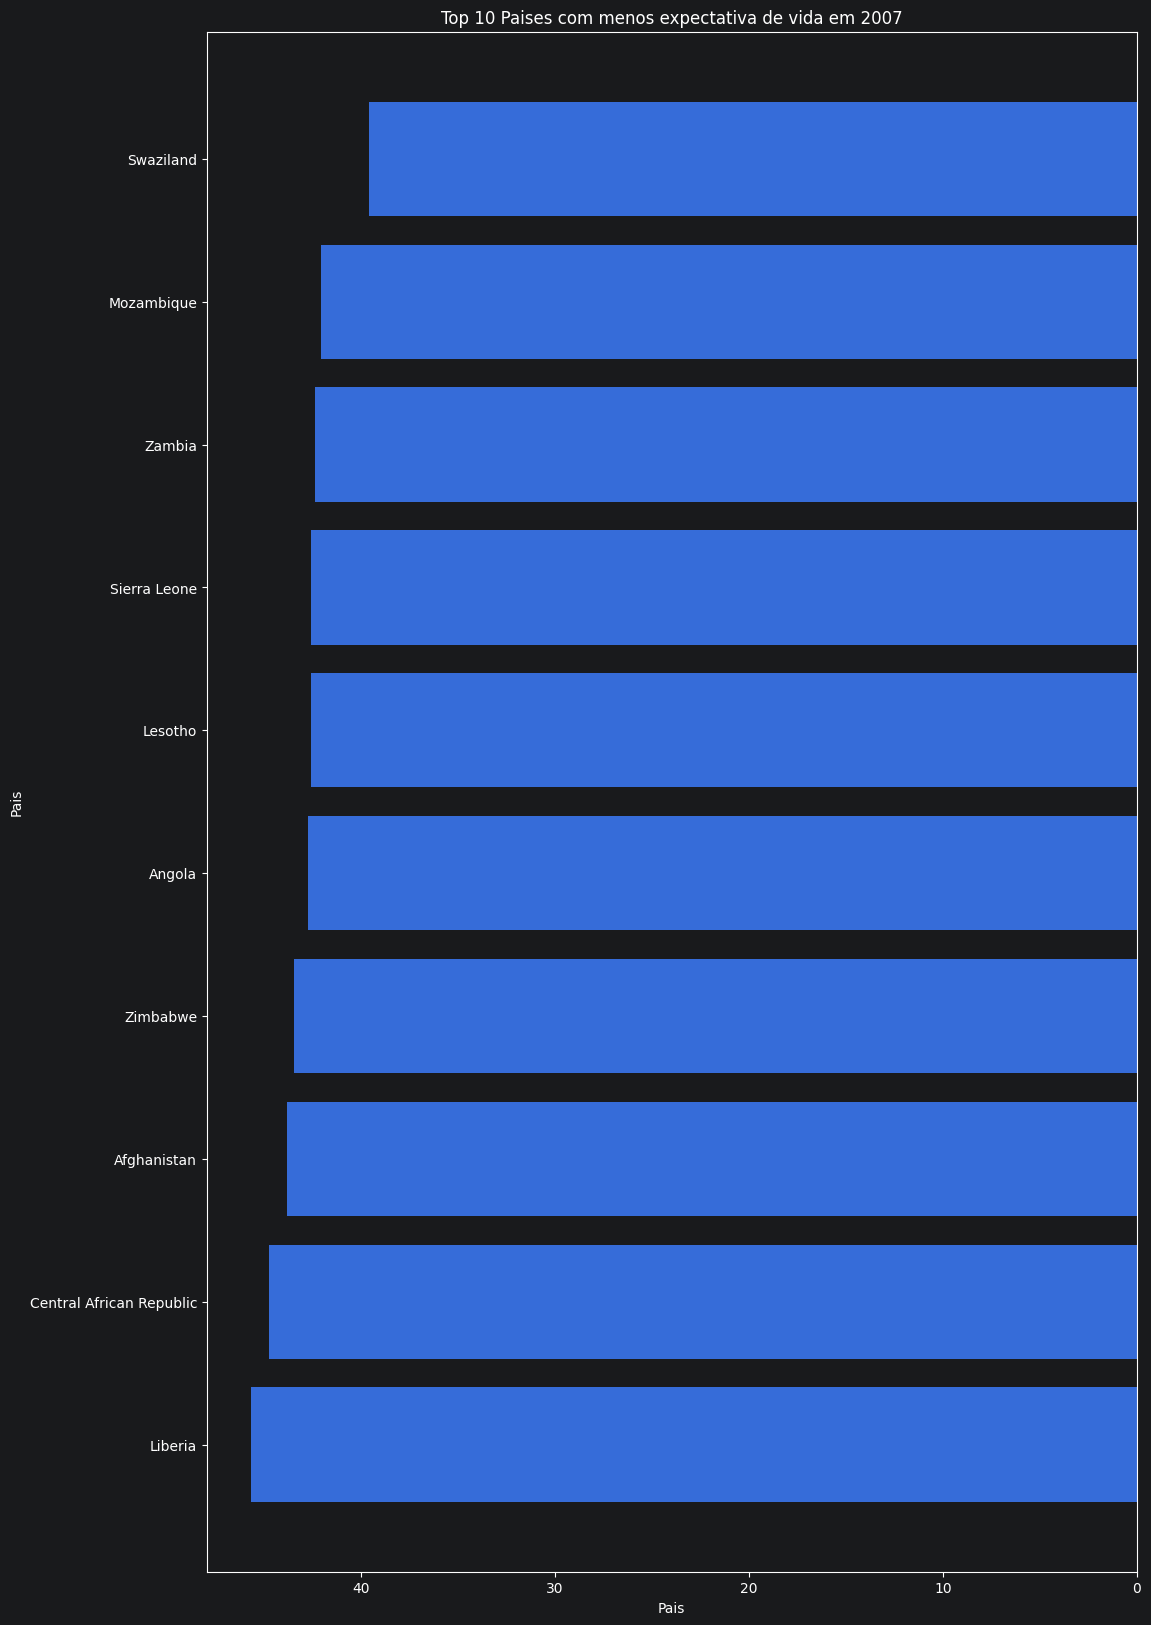

In [44]:
gerar_barh_grafico(
    ano=ano_mais_recente,
    data_frame=df,
    colunas=colunas,
    titulo=f"Top 10 Paises com menos expectativa de vida em {ano_mais_recente}",
    posicao=Posicao.FINAL,
    # quantidade=2
)


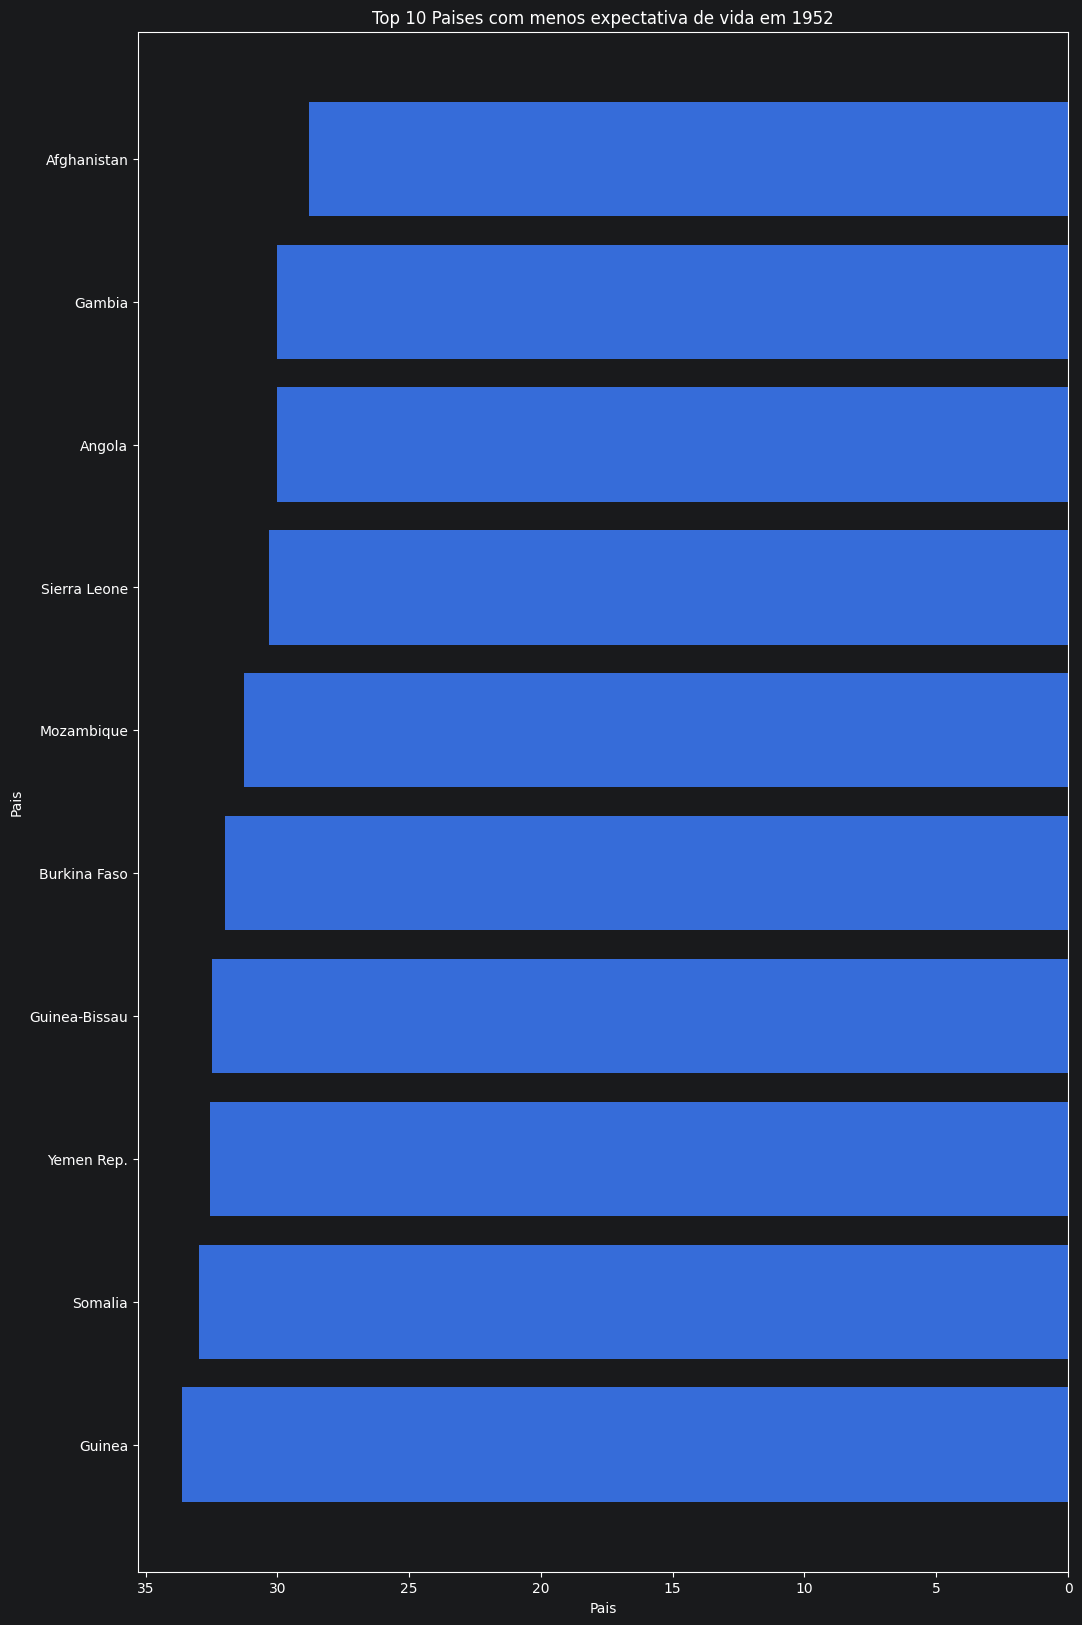

In [45]:
gerar_barh_grafico(
    ano=ano_mais_antigo,
    data_frame=df,
    colunas=colunas,
    titulo=f"Top 10 Paises com menos expectativa de vida em {ano_mais_antigo}",
    posicao=Posicao.FINAL,
    # quantidade=2
)


#### Evolução Por País

In [46]:
expect_vida_paises = (
    df.sort_values(by=['country','year']).groupby('country')
)
expect_vida_paises.value_counts()

country      year  pop         continent  lifeExp  gdpPercap 
Afghanistan  1952  8425333.0   Asia       28.801   779.445314    1
             2007  31889923.0  Asia       43.828   974.580338    1
             2002  25268405.0  Asia       42.129   726.734055    1
             1997  22227415.0  Asia       41.763   635.341351    1
             1987  13867957.0  Asia       40.822   852.395945    1
                                                                ..
Zimbabwe     1957  3646340.0   Africa     50.469   518.764268    1
             1952  3080907.0   Africa     48.451   406.884115    1
             2002  11926563.0  Africa     39.989   672.038623    1
             1972  5861135.0   Africa     55.635   799.362176    1
             2007  12311143.0  Africa     43.487   469.709298    1
Name: count, Length: 1704, dtype: int64

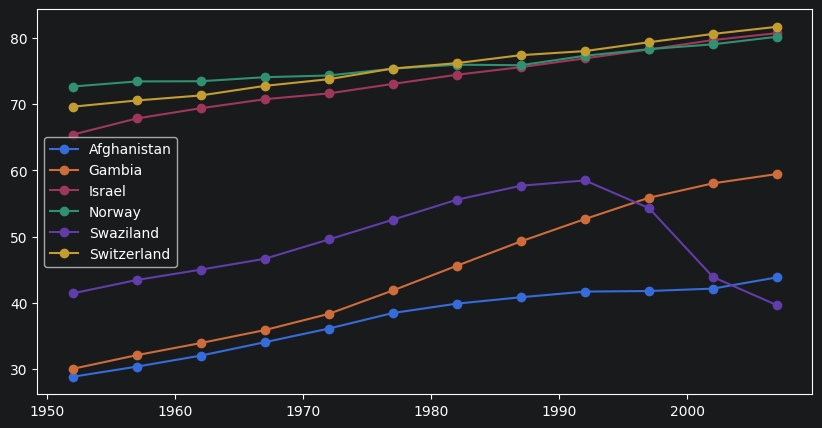

In [47]:
graf_evolu_pais(paises_por_ano=expect_vida_paises,paises=["Switzerland","Israel","Swaziland","Afghanistan","Gambia","Norway"])

#### Visualização Expectativa de Vida Por Continente

In [48]:
expect_vida_continente = df.groupby(["continent","year"])["lifeExp"].mean().reset_index()
expect_vida_continente.sort_values(by="lifeExp", ascending=False).head(10)


,continent,year,lifeExp
59,Oceania,2007,80.719500
58,Oceania,2002,79.740000
57,Oceania,1997,78.190000
47,Europe,2007,77.648600
56,Oceania,1992,76.945000
46,Europe,2002,76.700600
45,Europe,1997,75.505167
55,Oceania,1987,75.320000
44,Europe,1992,74.440100
54,Oceania,1982,74.290000


In [49]:
expect_vida_continente.sort_values(by="lifeExp").head(10)

,continent,year,lifeExp
0,Africa,1952,39.135500
1,Africa,1957,41.266346
2,Africa,1962,43.319442
3,Africa,1967,45.334538
24,Asia,1952,46.314394
4,Africa,1972,47.450942
25,Asia,1957,49.318544
5,Africa,1977,49.580423
26,Asia,1962,51.563223
6,Africa,1982,51.592865


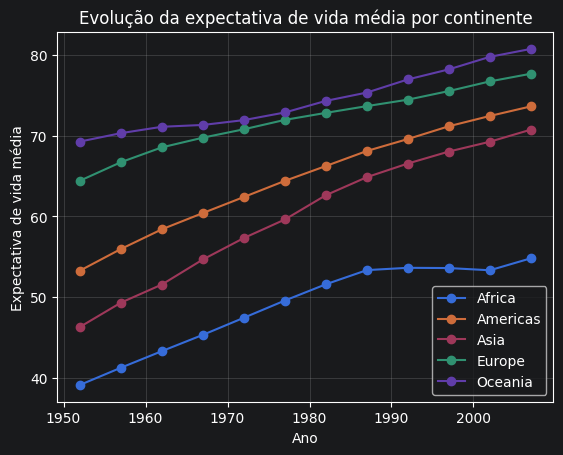

In [50]:
for continent in expect_vida_continente["continent"].unique():
    dados = expect_vida_continente[expect_vida_continente["continent"] == continent]
    plt.plot(dados["year"], dados["lifeExp"], label=continent,marker='o')

plt.title("Evolução da expectativa de vida média por continente")
plt.xlabel('Ano')
plt.ylabel("Expectativa de vida média")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()